In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/manue/Downloads/myexcel - myexcel.csv (1).csv")

In [4]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


In [6]:
df.describe()

,Number,Age,Weight,Salary
count,458.000000,458.000000,458.000000,4.470000e+02
mean,17.713974,26.934498,221.543668,4.833970e+06
std,15.966837,4.400128,26.343200,5.226620e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.025210e+06
50%,13.000000,26.000000,220.000000,2.836186e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


# Preprocessing

In [8]:
df['Height'] = np.random.randint(150,181, df.shape[0])

In [9]:
print("\nUpdated Dataset:")
print(df.info())


Updated Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    int32  
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int32(1), int64(3), object(4)
memory usage: 30.5+ KB
None


In [10]:
df['College'].fillna("Unknown", inplace=True)
df['Salary'].fillna(df['Salary'].median(), inplace=True)

In [11]:
print("\nUpdated Dataset:")
print(df.info())


Updated Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    int32  
 6   Weight    458 non-null    int64  
 7   College   458 non-null    object 
 8   Salary    458 non-null    float64
dtypes: float64(1), int32(1), int64(3), object(4)
memory usage: 30.5+ KB
None


# Distribution of Employees Across Each Team

In [13]:
team_distribution = df['Team'].value_counts()
team_percentage = (team_distribution / len(df)) * 100

In [14]:
team_percentage

Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
New York Knicks           3.493450
Milwaukee Bucks           3.493450
Brooklyn Nets             3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thunder     3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Miami Heat                3.275109
Charlotte Hornets         3.275109
Atlanta Hawks             3.275109
San Antonio Spurs         3.275109
Houston Rockets           3.275109
Boston Celtics            3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Sacramento Kings          3.275109
Phoenix Suns              3.275109
Los Angeles Lakers        3.275109
Los Angeles Clippers      3.275109
Golden State Warriors     3.275109
Toronto Raptors           3.275109
Philadelphia 76ers        3.275109
Dallas Mavericks          3.275109
Orlando Magic  

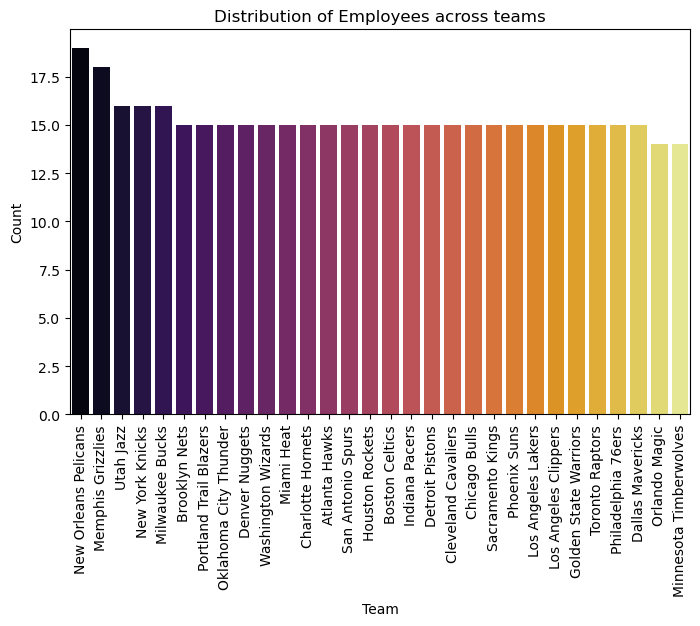

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x = team_distribution.index, y = team_distribution.values, palette='inferno')
plt.title("Distribution of Employees across teams")
plt.xticks(rotation=90)
plt.xlabel('Team')
plt.ylabel('Count')
plt.show()

# Segregate Employees Based on Positions

In [17]:
position_distribution = df['Position'].value_counts()

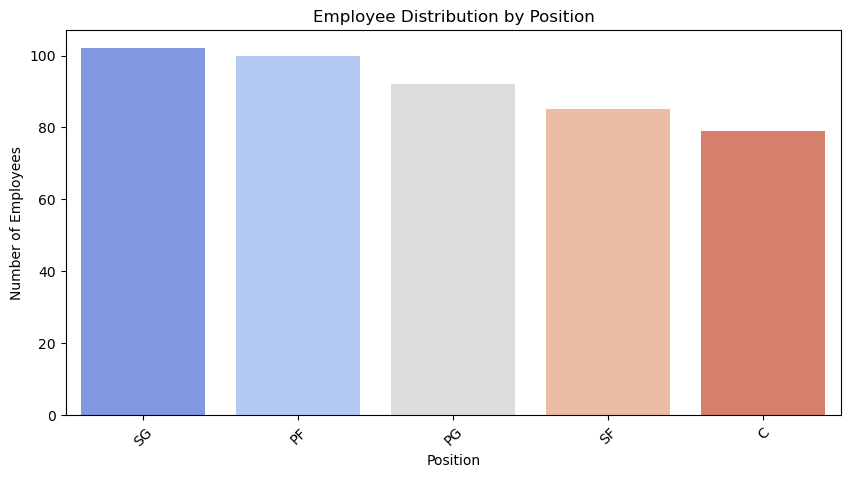

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(x=position_distribution.index, y=position_distribution.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.xlabel("Position")
plt.ylabel('Number of Employees')
plt.title('Employee Distribution by Position')
plt.show()

# Predominant Age Group

In [20]:
age_bins = [20, 30, 40, 50, 60]
age_labels = ["20-30", "30-40", "40-50", "50-60"]
df['age_group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
age_distribution = df['age_group'].value_counts()

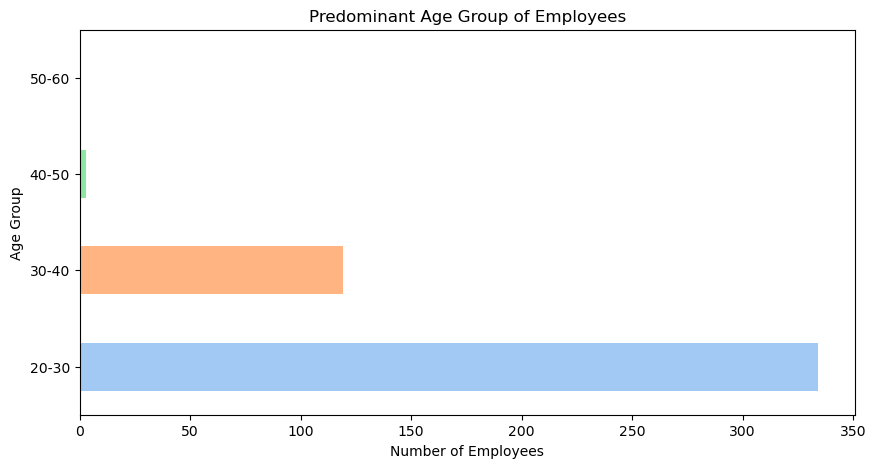

In [21]:
plt.figure(figsize=(10,5))
age_distribution.plot(kind='barh', color=sns.color_palette('pastel', len(age_distribution)))
plt.xlabel("Number of Employees")
plt.ylabel("Age Group")
plt.title("Predominant Age Group of Employees")
plt.show()

# Highest Salary Expenditure by Team and Position

In [23]:
salary_by_team = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
salary_by_position = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)

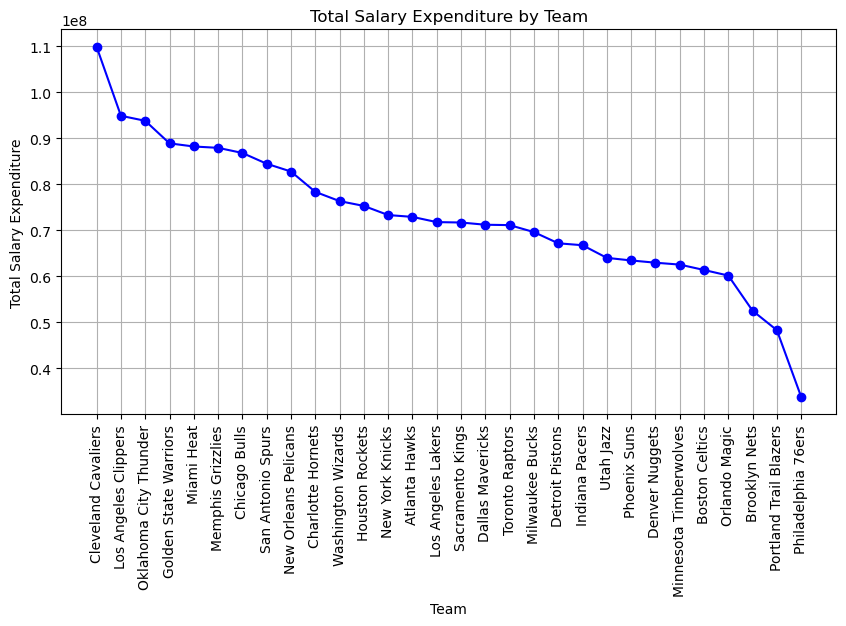

In [24]:
plt.figure(figsize=(10,5))
plt.plot(salary_by_team.index, salary_by_team.values, marker='o', linestyle='-', color='b')
plt.xticks(rotation=90)
plt.xlabel("Team")
plt.ylabel("Total Salary Expenditure")
plt.title("Total Salary Expenditure by Team")
plt.grid()
plt.show()

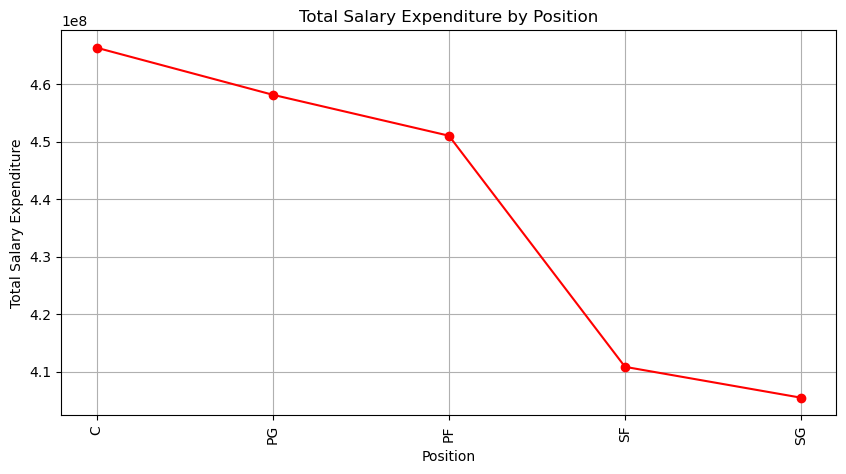

In [25]:
plt.figure(figsize=(10,5))
plt.plot(salary_by_position.index, salary_by_position.values, marker='o', linestyle='-', color='r')
plt.xticks(rotation=90)
plt.xlabel("Position")
plt.ylabel("Total Salary Expenditure")
plt.title("Total Salary Expenditure by Position")
plt.grid()
plt.show()

# Correlation between Age and Salary

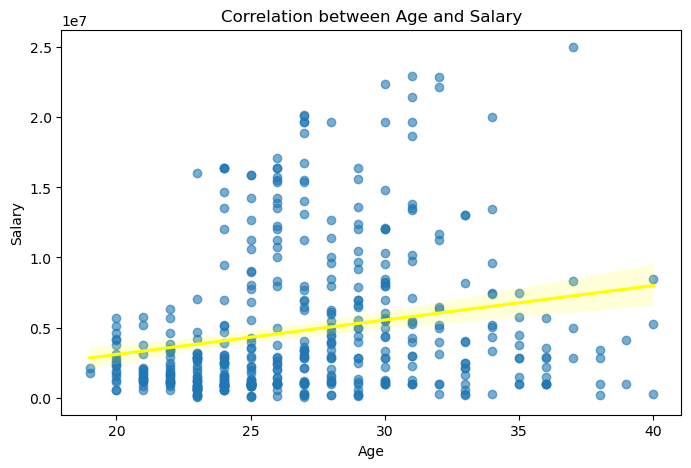

In [27]:
plt.figure(figsize=(8,5))
sns.regplot(x=df['Age'], y=df['Salary'], scatter_kws={'alpha':0.6}, line_kws={'color':'yellow'})
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Correlation between Age and Salary")
plt.show()

In [28]:
correlation = df['Age'].corr(df['Salary'])
print(f"Correlation between Age and Salary is : {correlation:.2f}")

Correlation between Age and Salary is : 0.21


# Data Story

In [72]:
insights = f"""
1. The highest number of employees are in New Orleans Pelicans.
2. The highest number of employees holds the position of SG.
3. The predominant age group is 20-30.
4. The team Cleveland Cavaliers and Position C has the highest salary expenditure.
5. There is a {correlation:.2f} correlation between age and salary, indicating a weak positive relationship between age and salary
"""
print(insights)


1. The highest number of employees are in New Orleans Pelicans.
2. The highest number of employees holds the position of SG.
3. The predominant age group is 20-30.
4. The team Cleveland Cavaliers and Position C has the highest salary expenditure.
5. There is a 0.21 correlation between age and salary, indicating a weak positive relationship between age and salary

